# Exploratory Data Analysis and Introduction

### Objectives
1. Introduce the project, dataset, and analysis objectives.
2. Understand the overall characteristics and quality of the dataset through exploratory data analysis.
3. Explore relationships, patterns, and trends among the key variables.
4. Generate insights that will answer the project's analytical questions.

 ### Questions to Answer
1. What are the most demanded skills for the top 3 most popular data roles?
2. How are in-demand skills trending for Data Analysts?
3. How well do jobs and skills pay for Data Analysts?
4. What is the most optimal skill to learn for Data Analysts? (High Demand AND High Paying)

I'll be focusing on US Data Analyst roles, but you can adapt to any of the following:

## 1. Import Libraries

In [2]:
# there are all libraries I will need in this notebook.
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
# import numpy as np 
import ast


## 2. Load dataset 


In [3]:
df=pd.read_csv("../data/data_jobs.csv")
df.head(3)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."


## 3. Data Inspection 

In [4]:
df.shape # there is a 780,000+ rows and 17 columns table in the (csv file)

(785741, 17)

In [5]:
df.columns

# Observation:
# - Column names are stored as strings and follow snake_case naming convention.
# - Reviewing column names helps understand the available features and their purpose.

Index(['job_title_short', 'job_title', 'job_location', 'job_via',
       'job_schedule_type', 'job_work_from_home', 'search_location',
       'job_posted_date', 'job_no_degree_mention', 'job_health_insurance',
       'job_country', 'salary_rate', 'salary_year_avg', 'salary_hour_avg',
       'company_name', 'job_skills', 'job_type_skills'],
      dtype='str')

In [6]:
#df.dtypes 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   job_title_short        785741 non-null  str    
 1   job_title              785740 non-null  str    
 2   job_location           784696 non-null  str    
 3   job_via                785733 non-null  str    
 4   job_schedule_type      773074 non-null  str    
 5   job_work_from_home     785741 non-null  bool   
 6   search_location        785741 non-null  str    
 7   job_posted_date        785741 non-null  str    
 8   job_no_degree_mention  785741 non-null  bool   
 9   job_health_insurance   785741 non-null  bool   
 10  job_country            785692 non-null  str    
 11  salary_rate            33067 non-null   str    
 12  salary_year_avg        22003 non-null   float64
 13  salary_hour_avg        10662 non-null   float64
 14  company_name           785723 non-null  str    

### Data Type Observations

- The `job_posted_date` column is stored as an object type. It should be converted to datetime for extracting year, month, and day information.
- The `job_skills` column contains skill lists stored as objects. It may need to be exploded later for individual skill analysis.
- Salary-related columns contain a large number of missing values.

In [7]:
df.sample(4)   #some random records 

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
381475,Data Scientist,Data Scientist - Now Hiring,"Batavia, OH",via Snagajob,Full-time and Part-time,False,Georgia,2023-12-06 19:20:28,False,False,United States,hour,NaN,36.599998,Hillenbrand,"['python', 'java', 'sas', 'sas', 'r', 'sql', '...","{'analyst_tools': ['sas', 'excel', 'powerpoint..."
347121,Senior Data Engineer,Senior Principal Data Engineer 114-005 Jobs,"Herndon, VA",via Clearance Jobs,Full-time,False,Sudan,2023-05-18 00:10:56,False,False,Sudan,NaN,NaN,NaN,IC-CAP,"['python', 'java', 'scala', 'postgresql', 'ela...","{'cloud': ['azure', 'aws'], 'databases': ['pos..."
640139,Data Analyst,Contrôleur de Gestion - Data Analyst H/F,"Annecy, France",via LinkedIn,Full-time,False,France,2023-06-16 12:56:53,False,False,France,NaN,NaN,NaN,TALEXIM,"['sql', 'excel']","{'analyst_tools': ['excel'], 'programming': ['..."
72909,Data Engineer,Data Engineer (Enterprise Master Data Management),"Edinburgh, UK",via LinkedIn,Full-time,False,United Kingdom,2023-07-12 00:22:34,True,False,United Kingdom,NaN,NaN,NaN,Wood Mackenzie,"['sql', 'aws']","{'cloud': ['aws'], 'programming': ['sql']}"


In [8]:
df.describe()

# Summary statistics for numerical columns.( yearly and hourly salary rate)
# Salary distributions are right-skewed, with a small number of high-paying jobs increasing the upper range.
# Potential outliers will be considered during salary analysis.

,salary_year_avg,salary_hour_avg
count,22003.000000,10662.000000
mean,123286.274072,47.016598
std,48312.449482,21.890738
min,15000.000000,8.000000
25%,90000.000000,27.500000
50%,115000.000000,45.980000
75%,150000.000000,61.159996
max,960000.000000,391.000000


In [9]:
df.isna().sum() 
# Checking missing values in each column.

# Observations:
# - Salary-related columns have the highest number of missing values because many job postings do not provide salary information.
# - job_skills and job_type_skills have missing values because some postings do not include required skills.
# - job_location, job_schedule_type, and company_name have a small number of missing values compared to the total dataset size.
# - These missing values should be evaluated before deciding whether to remove or handle them.

job_title_short               0
job_title                     1
job_location               1045
job_via                       8
job_schedule_type         12667
job_work_from_home            0
search_location               0
job_posted_date               0
job_no_degree_mention         0
job_health_insurance          0
job_country                  49
salary_rate              752674
salary_year_avg          763738
salary_hour_avg          775079
company_name                 18
job_skills               117037
job_type_skills          117037
dtype: int64

In [10]:
df.duplicated().sum() # there are 101 duplicated records. later in cleaning it can be dropped

np.int64(101)

In [11]:
df['job_health_insurance'].value_counts() # this is showing more jobs are without health insurance.

job_health_insurance
False    699244
True      86497
Name: count, dtype: int64

In [12]:
df['job_work_from_home'].value_counts() # this shows how many jobs are remote and onsite.

job_work_from_home
False    716189
True      69552
Name: count, dtype: int64

In [13]:
df['job_no_degree_mention'].value_counts() # this shows in how many jobs degree is mentioned and is not

job_no_degree_mention
False    544965
True     240776
Name: count, dtype: int64

In [14]:
df['salary_rate'].value_counts()

# Salary frequency distribution.
# Yearly salary is the most common, followed by hourly salary.
# Yearly salary will be used for analysis due to more available records.

salary_rate
year     22004
hour     10662
month      382
week        10
day          9
Name: count, dtype: int64

In [15]:
df['job_schedule_type'].value_counts().head()
# full time domination after contractor.

job_schedule_type
Full-time                  701727
Contractor                  34793
Internship                   8742
Part-time                    7881
Full-time and Part-time      6287
Name: count, dtype: int64

In [16]:
df['job_schedule_type'].count()    # how many non- null values are ther.

np.int64(773074)

In [17]:
df['job_title_short'].unique()    # unique data roles

<StringArray>
[     'Senior Data Engineer',              'Data Analyst',
             'Data Engineer',          'Business Analyst',
            'Data Scientist', 'Machine Learning Engineer',
       'Senior Data Analyst',            'Cloud Engineer',
     'Senior Data Scientist',         'Software Engineer']
Length: 10, dtype: str

## 4. Data Cleaning

In [18]:
# Remove duplicate records
df_cleaned = df.drop_duplicates().copy()

print(f"Rows before removing duplicates: {len(df)}")
print(f"Rows after removing duplicates: {len(df_cleaned)}")
print(f"Duplicate rows removed: {len(df) - len(df_cleaned)}")

Rows before removing duplicates: 785741
Rows after removing duplicates: 785640
Duplicate rows removed: 101


In [19]:
df_cleaned['job_posted_date']=pd.to_datetime(df_cleaned['job_posted_date'])

In [20]:
#job skill should be list object 
df_cleaned['job_skills']=df_cleaned['job_skills'].apply(lambda job_skill: ast.literal_eval(job_skill) if pd.notna(job_skill) else job_skill)

In [21]:
# 
# exploded dataset
df_exploded=df_cleaned.explode(column='job_skills')
#Now count the job skills which is not a list anymore

df_exploded['job_skills'].value_counts().head(10)   # it shows the list below is the most common skills in data jobs


job_skills
sql         384822
python      380883
aws         145377
azure       132525
r           130884
tableau     127207
excel       127011
spark       114604
power bi     98141
java         85607
Name: count, dtype: int64

In [ ]:
# #job_type_skills should be dictionary obj
df_cleaned['job_type_skills']=df_cleaned['job_type_skills'].apply(lambda job_type: ast.literal_eval(job_type) if pd.notna(job_type) else job_type)


In [23]:
skill_type_dicts=df_cleaned["job_type_skills"].dropna() # series of dictionaries

skill_category=set()

for skill_types in skill_type_dicts:   #  accessing one dictionary among series of dictionaries
    for skill_type in skill_types.keys():
        skill_category.add(skill_type)

# this is all the categories in the dataset
skill_category 

{'analyst_tools',
 'async',
 'cloud',
 'databases',
 'libraries',
 'os',
 'other',
 'programming',
 'sync',
 'webframeworks'}

In [24]:
df_cleaned.info()

<class 'pandas.DataFrame'>
Index: 785640 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785640 non-null  str           
 1   job_title              785639 non-null  str           
 2   job_location           784595 non-null  str           
 3   job_via                785632 non-null  str           
 4   job_schedule_type      772975 non-null  str           
 5   job_work_from_home     785640 non-null  bool          
 6   search_location        785640 non-null  str           
 7   job_posted_date        785640 non-null  datetime64[us]
 8   job_no_degree_mention  785640 non-null  bool          
 9   job_health_insurance   785640 non-null  bool          
 10  job_country            785591 non-null  str           
 11  salary_rate            33066 non-null   str           
 12  salary_year_avg        22002 non-null   float64       
 13  

In [25]:
df.isna().sum()


#Most missing values are expected because not every job posting provides 
# salary, skills, company information, or schedule details. 
# These missing values will be preserved and handled only when required for a specific analysis.

job_title_short               0
job_title                     1
job_location               1045
job_via                       8
job_schedule_type         12667
job_work_from_home            0
search_location               0
job_posted_date               0
job_no_degree_mention         0
job_health_insurance          0
job_country                  49
salary_rate              752674
salary_year_avg          763738
salary_hour_avg          775079
company_name                 18
job_skills               117037
job_type_skills          117037
dtype: int64

## 5. EDA
 

### General exploration for the dataset

In [26]:
df_EDA=df_cleaned.copy()


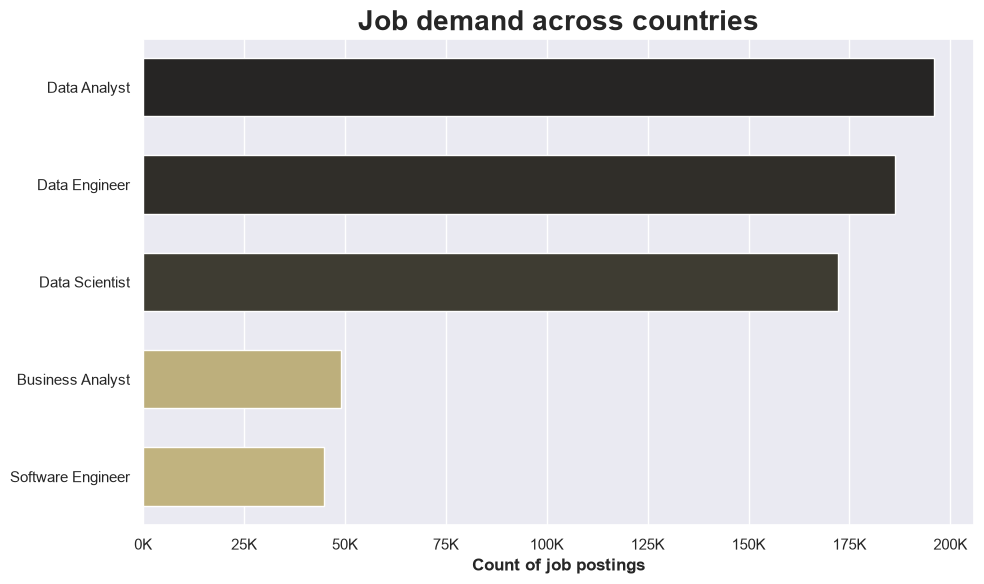

In [107]:
# top 5 jobs, demanded in 2023 across all countries 
jobs_demand=df_EDA['job_title_short'].value_counts().head().to_frame().reset_index()



sns.set_theme(style='darkgrid')
plt.figure(figsize=(10,6))
sns.barplot(
    data=jobs_demand,
    x="count",
    y="job_title_short"
    ,width=0.6,
    hue='count',
    palette='dark:y_r'
)
plt.title("Job demand across countries", weight="bold", fontsize=20)
plt.xlabel("Count of job postings", weight='bold',fontsize=12)
plt.ylabel("")
plt.legend().remove()
ax1=plt.gca()
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'{int(x/1000)}K'))
plt.tight_layout()
plt.show()

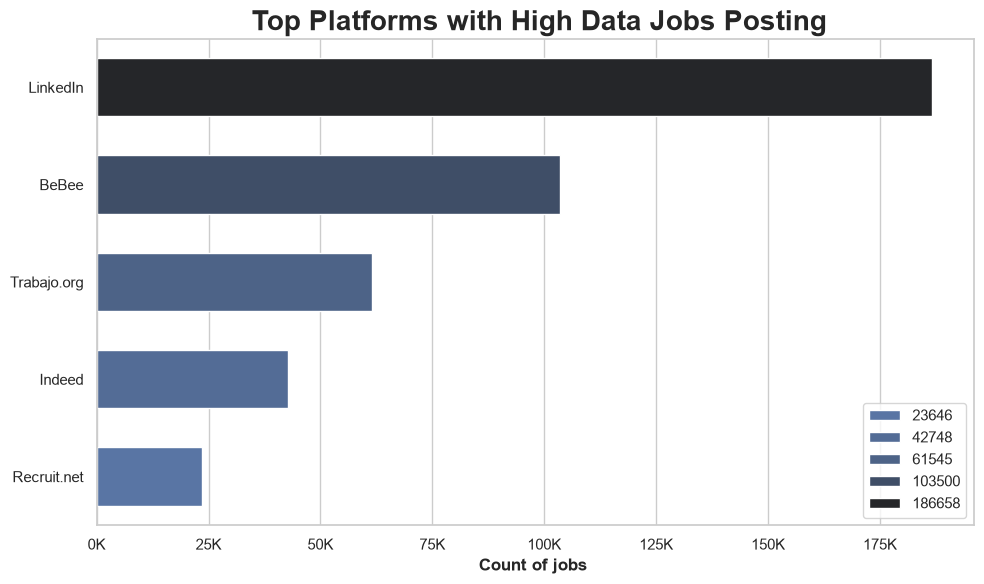

In [106]:
# top 5 platforms posted jobs

top_platforms= df_EDA["job_via"].str.replace("via ", "").value_counts().head().reset_index()

sns.set_theme(style='whitegrid')
plt.figure(figsize=(10,6))
sns.barplot(
    data=top_platforms,
    x="count",
    y="job_via"
    ,width=0.6,
    hue='count',
    palette='dark:b_r'
)
plt.title(" Top Platforms with High Data Jobs Posting", weight="bold", fontsize=20)
plt.xlabel("Count of jobs ", weight='bold',fontsize=12)
plt.ylabel("")
plt.legend().remove()
ax=plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'{int(x/1000)}K'))
plt.legend()
plt.tight_layout()
plt.show()

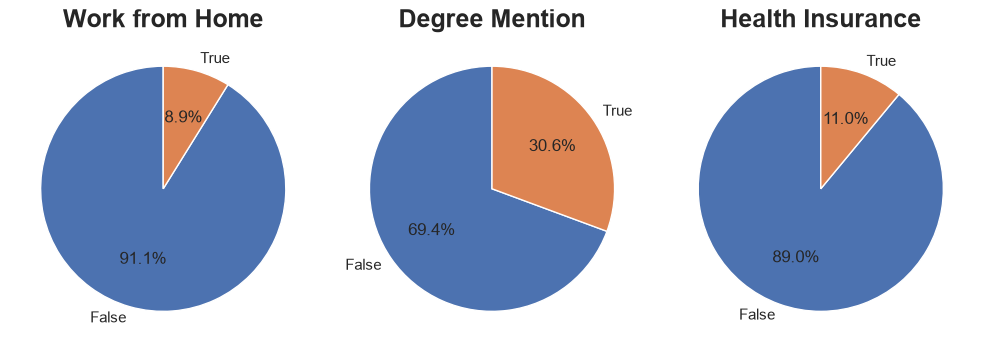

In [118]:
# categorical features analysis including remote & onsite jobs, job degree mentioned or not, and health insurance provided jobs. 
# job apporutnities 
fig, axis=plt.subplots(1,3,figsize=(10,6))


dict_cols={
    'job_work_from_home':'Work from Home',
    'job_no_degree_mention': 'Degree Mention',
    'job_health_insurance':'Health Insurance'
}
for index, (job, title) in enumerate(dict_cols.items()):
    axis[index].pie(df_EDA[job].value_counts(),labels=['False', 'True'], autopct='%1.1f%%', startangle=90)
    axis[index].set_title(title, weight="bold", fontsize=18)

plt.tight_layout()
plt.show()

In [30]:
# most common schedule types jobs
schedule_df = df_EDA[["job_schedule_type"]].dropna().copy()

#replacing names Pekerjaan tetap and Kontraktor
schedule_df["job_schedule_type"] = schedule_df["job_schedule_type"].replace({
    "Pekerjaan tetap": "Full-time",
    "Kontraktor": "Contractor"
})

#
schedule_df["job_schedule_type"] = (
    schedule_df["job_schedule_type"]
    .str.split(r",?\s+and\s+|,\s*")
)

#explode them in different schedule type names
schedule_df=schedule_df.explode('job_schedule_type').value_counts().reset_index()

#showing dataframe which is built in this process
schedule_df

# so the most important types are top 4 
schedule_df=schedule_df.head(4)

#for better quality of analysis there are what I did:
# "Pekerjaan tetap" and "Kontraktor", They are Indonesian/Malay words so they need to be replaced m 
# there was combinations of schedule type names; which regex is used to solve the problem and explode for clear frequency counts 


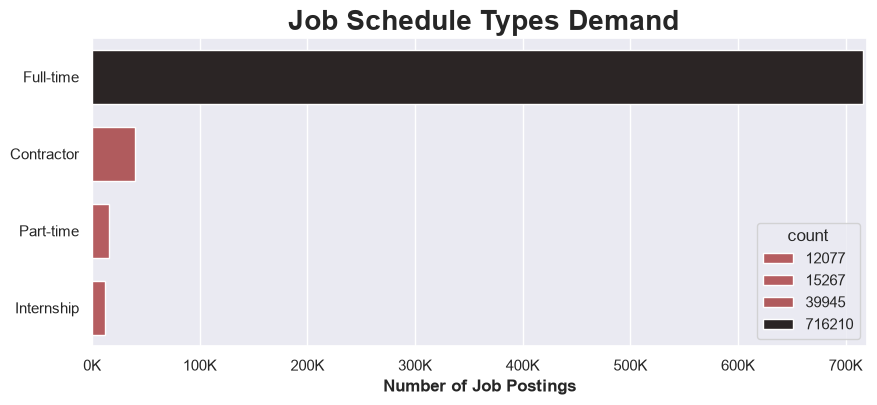

In [146]:

sns.set_theme(style='darkgrid')

plt.figure(figsize=(10,4))

sns.barplot(
    data=schedule_df,
    x="count",
    y="job_schedule_type",
    hue="count",
    palette="dark:r_r",
    width=0.7
)

plt.title(" Job Schedule Types Demand", weight="bold", fontsize=20)
plt.xlabel("Number of Job Postings", weight='bold',fontsize=12)
plt.ylabel("")
plt.xlim(0,720000)
ax=plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'{int(x/1000)}K'))
plt.show()

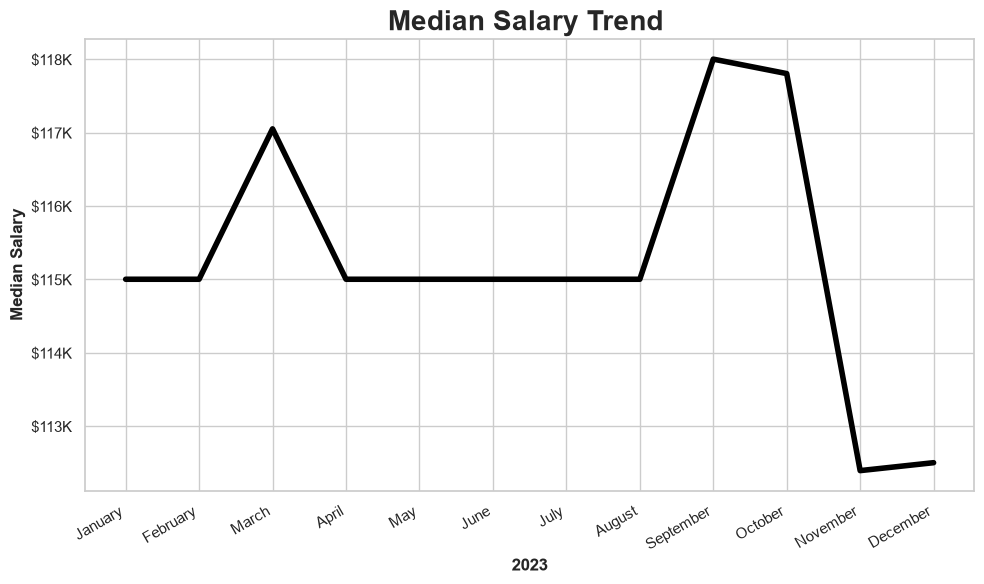

In [147]:
# Median yearly salary trend by month

month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

salary_trend = (
    df_EDA
    .dropna(subset=["salary_year_avg"])
    .groupby(df_EDA["job_posted_date"].dt.month_name())["salary_year_avg"]
    .median()
    .reindex(month_order)
)


plt.figure(figsize=(10,6))
sns.set_style('whitegrid')


sns.lineplot(
    x=salary_trend.index,
    y=salary_trend.values,
    linestyle="-",
    # marker="*",
    markersize=10,
    linewidth=4,
    color='black'
    
)

plt.title("Median Salary Trend ", fontsize=20, weight="bold")
plt.xlabel("")
plt.ylabel("Median Salary", weight='bold',fontsize=12)
plt.xlabel("2023", weight='bold',fontsize=12)

ax = plt.gca()
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f"${int(x/1000)}K")
)

plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

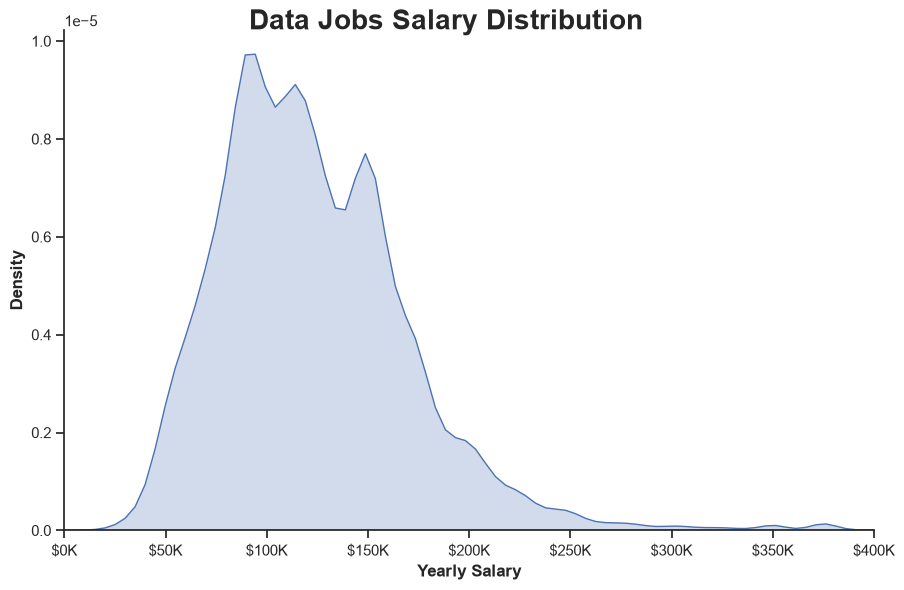

In [101]:
# salary distribution 
salary_df = df_EDA.dropna(subset=["salary_year_avg"])

sns.set_theme(style="ticks")
plt.figure(figsize=(10,6))
g = sns.displot(
    data=salary_df,
    x="salary_year_avg",
    kind="kde",
    fill=True,
    height=6,
    aspect=1.5
)

g.set_axis_labels("Yearly Salary", "Density", weight='bold',fontsize=12)
g.figure.suptitle(" Data Jobs Salary Distribution", fontsize=20, weight="bold")

ax = g.ax
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f"${int(x/1000)}K")
)

ax.set_xlim(0, 400000)

plt.show()

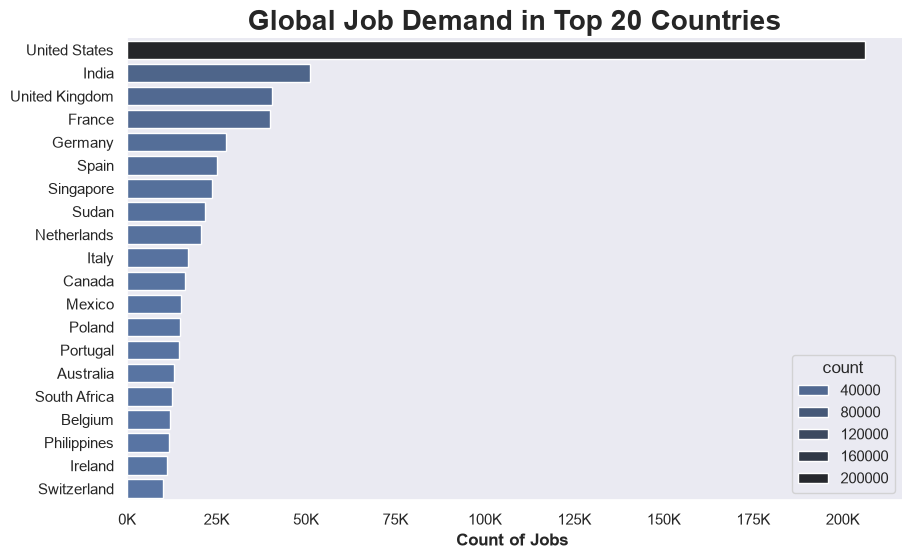

In [148]:
# number of job posted in all countries
country_df=df_EDA['job_country'].value_counts().head(20).to_frame()

sns.set_theme(style='dark')
plt.figure(figsize=(10,6))


sns.barplot(data=country_df, x='count', y='job_country', hue='count', palette='dark:b_r')
plt.title("Global Job Demand in Top 20 Countries", weight="bold", fontsize=20)
plt.ylabel("")
plt.xlabel("Count of Jobs ", weight='bold',fontsize=12)
ax=plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'{int(x/1000)}K'))
sns.despine()
plt.show()


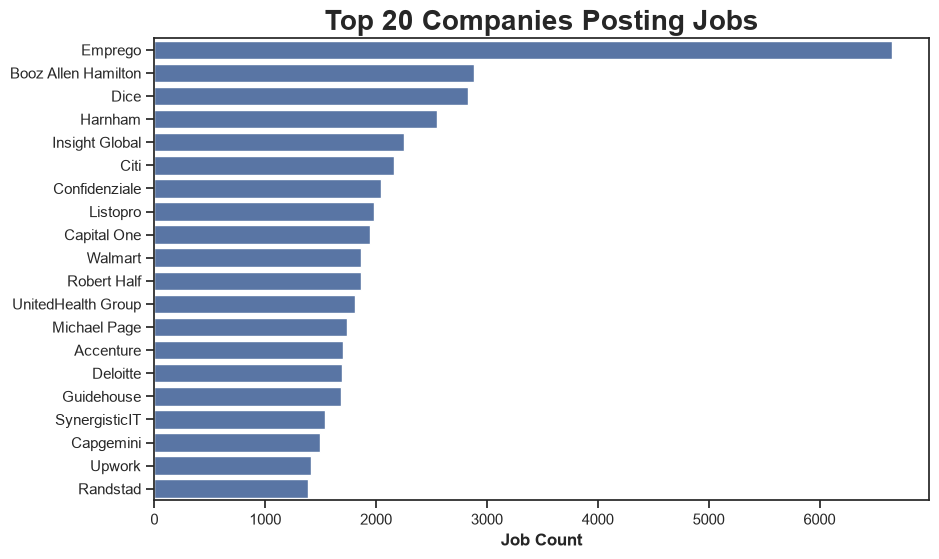

In [54]:
# Top 20 company names
top_companies = df_EDA["company_name"].value_counts().head(20).index

sns.set_theme(style='ticks')
plt.figure(figsize=(10,6))
sns.countplot(
    data=df_EDA[df_EDA["company_name"].isin(top_companies)],
    y="company_name",
    order=top_companies,
    
    legend=False
)

plt.title("Top 20 Companies Posting Jobs", weight="bold", fontsize=20)
plt.xlabel("Job Count", weight='bold',fontsize=12)
plt.ylabel("")
plt.show()


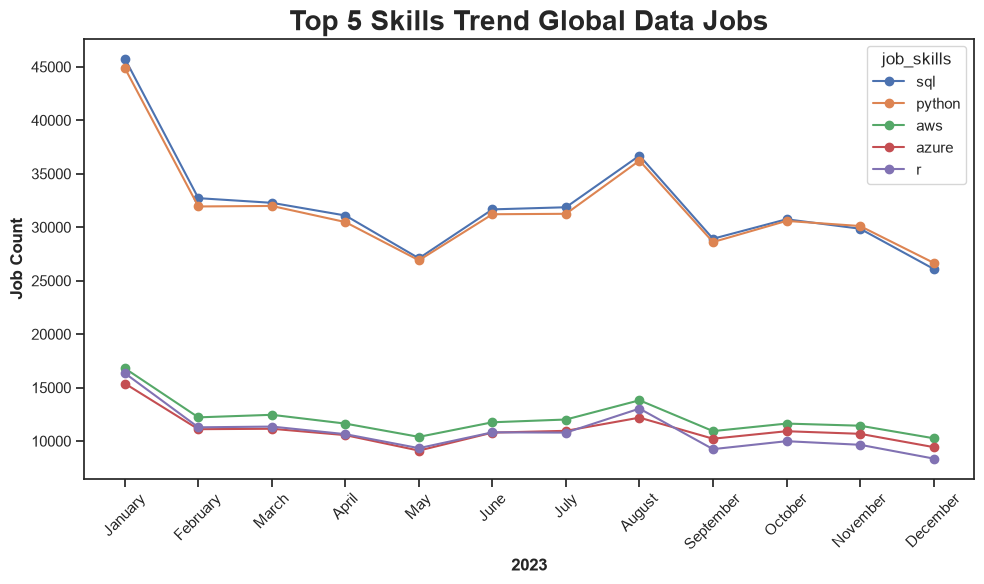

In [99]:
# Top 5 most demanded skills over time

skills_df = df_EDA[["job_posted_date", "job_skills"]].dropna().copy()

skills_df['job_posted_month_no']=skills_df['job_posted_date'].dt.month

skills_df_exploded=skills_df.explode('job_skills')

df_pivot=skills_df_exploded.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size',fill_value=0)
df_pivot.loc['total']=df_pivot.sum()
df_pivot=df_pivot[df_pivot.loc['total'].sort_values(ascending=False).index]
df_pivot=df_pivot.drop('total')
df_pivot=df_pivot.reset_index()
df_pivot['job_posted_month']=df_pivot['job_posted_month_no'].apply(lambda x: pd.to_datetime(x,format='%m').strftime("%B"))
df_pivot=df_pivot.set_index('job_posted_month')
df_pivot=df_pivot.drop(columns='job_posted_month_no')

df_pivot=df_pivot.iloc[:,:5]
df_pivot.plot(kind='line',marker="o",figsize=(10, 6))


plt.xticks(ticks=range(len(df_pivot.index)),
           labels=df_pivot.index,
           rotation=45)


plt.title("Top 5 Skills Trend Global Data Jobs", fontsize=20, weight="bold")
plt.xlabel("")
plt.ylabel("Job Count", weight='bold',fontsize=12)
plt.xlabel("2023", weight='bold',fontsize=12)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


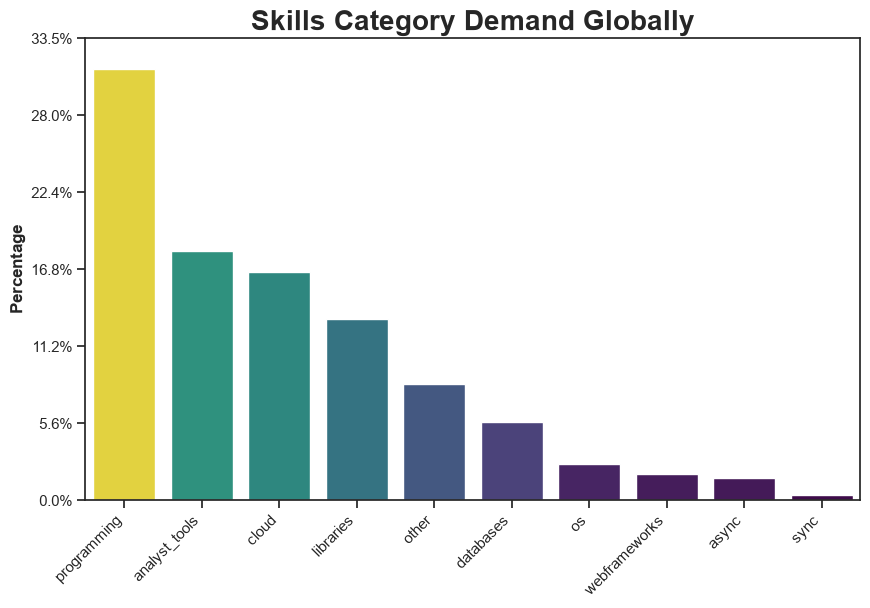

In [149]:
from matplotlib.ticker import PercentFormatter, FuncFormatter



skill_type_dicts=df_EDA["job_type_skills"].dropna() # series of dictionaries
category_count = {}

for skill_types in skill_type_dicts:
    for skill_type in skill_types.keys():
        if skill_type in category_count:
            category_count[skill_type] += 1
        else:
            category_count[skill_type] = 1

#count of all categories to visualize 
category_count


# convert to dataframe 
category_df = pd.DataFrame(category_count.items()  ,   columns=["category", "count"])


category_df = category_df.sort_values(by="count", ascending=False)
# visualization bar chart 

sns.set_theme(style='ticks')
plt.figure(figsize=(10,6))
sns.barplot(data=category_df, x='category', y='count', hue='count',palette="viridis"  , legend=False)
plt.xticks(rotation=45,  ha="right")

# in y axis showing the percentage instead of numbers 
plt.ylim(0,600000)
total = category_df["count"].sum()
ax = plt.gca()
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda y, pos: f"{y / total:.1%}")
)

plt.title("Skills Category Demand Globally", weight='bold', fontsize=20)
plt.xlabel("")
plt.ylabel("Percentage",weight='bold',fontsize=12)
plt.show()


###                                         --------< EDA for UK >------------

In [38]:
df_UK=df_EDA[df_EDA['job_country']=='United Kingdom'].copy()
df_UK.info() 

<class 'pandas.DataFrame'>
Index: 40374 entries, 15 to 785676
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   job_title_short        40374 non-null  str           
 1   job_title              40374 non-null  str           
 2   job_location           40360 non-null  str           
 3   job_via                40374 non-null  str           
 4   job_schedule_type      40045 non-null  str           
 5   job_work_from_home     40374 non-null  bool          
 6   search_location        40374 non-null  str           
 7   job_posted_date        40374 non-null  datetime64[us]
 8   job_no_degree_mention  40374 non-null  bool          
 9   job_health_insurance   40374 non-null  bool          
 10  job_country            40374 non-null  str           
 11  salary_rate            290 non-null    str           
 12  salary_year_avg        287 non-null    float64       
 13  salary_hour_avg

#### Which jobs are common in UK?

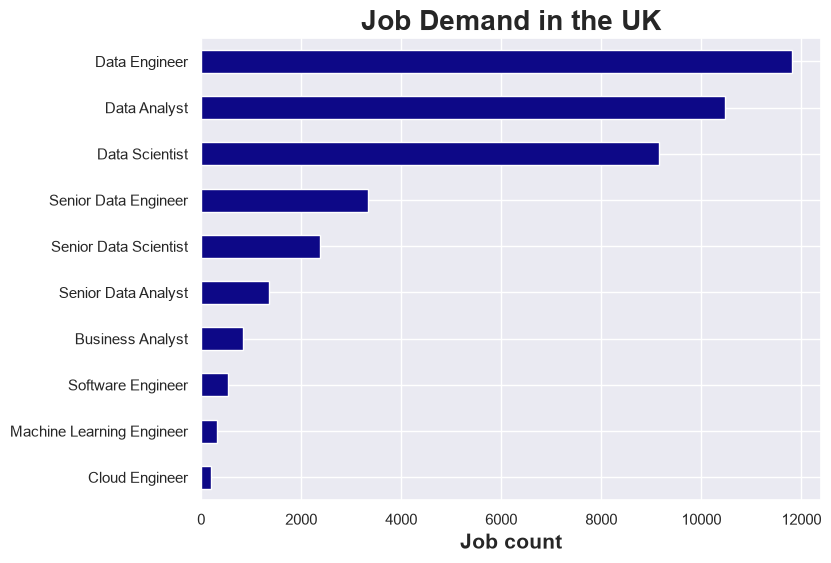

In [109]:
df_UK['job_title_short'].value_counts().sort_values(ascending=True).plot(kind='barh', colormap="plasma",figsize=(8,6))
plt.ylabel("")
plt.xlabel("Job count", weight='bold',fontsize=15)
plt.title("Job Demand in the UK", weight='bold', fontsize=20)
plt.show()
#job demand shows Data engineering is most posted job

#### Which companies are top companies posted jobs in UK?


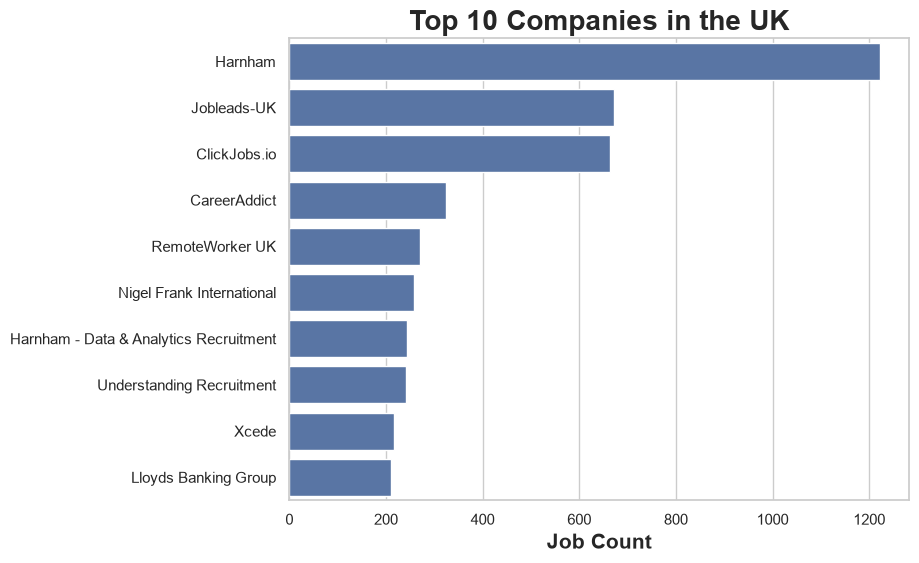

In [130]:

top_companies = df_UK["company_name"].value_counts().head(10).index

sns.set_theme(style='whitegrid')
sns.countplot(
    data=df_UK[df_UK["company_name"].isin(top_companies)],
    y="company_name",
    order=top_companies,
    
    legend=False
)

plt.title("Top 10 Companies in the UK", weight="bold", fontsize=20)
plt.xlabel("Job Count", weight='bold',fontsize=15)
plt.ylabel("")
plt.show()

#### Data JOb Oppotunity in the UK

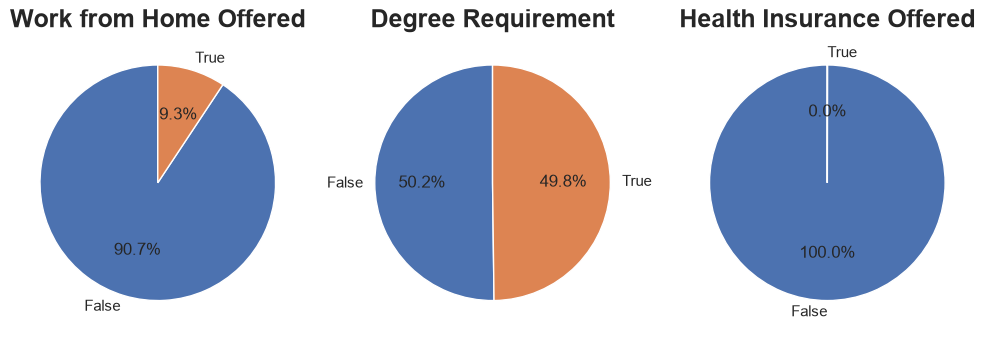

In [131]:
dict_column = {
    'job_work_from_home': 'Work from Home Offered',
    'job_no_degree_mention': 'Degree Requirement',
    'job_health_insurance': 'Health Insurance Offered'
}

fig, ax = plt.subplots(1, 3, figsize=(10,6))
for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df_UK[column].value_counts(), labels=['False', 'True'], autopct='%1.1f%%', startangle=90)
    ax[i].set_title(title,weight='bold', fontsize=18 )
plt.tight_layout()
plt.show()

#### Salary distribution in the UK for differnt data jobs

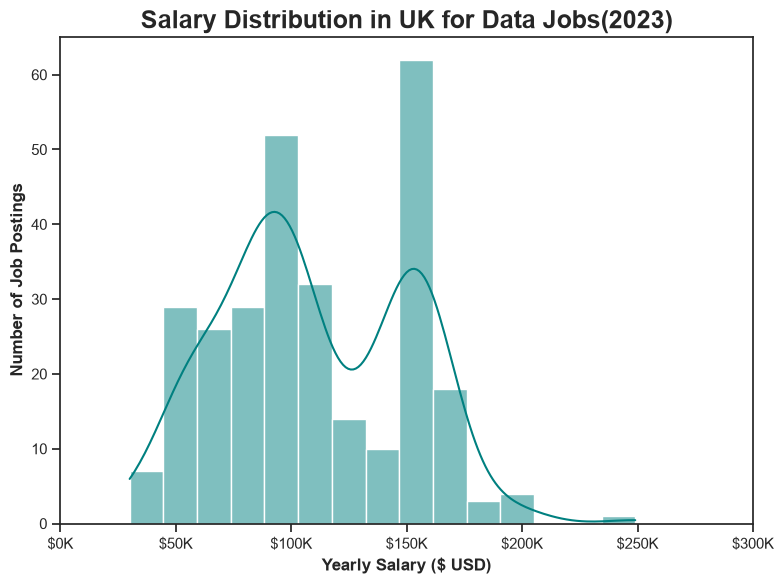

In [124]:
# salary distribution 
salary_df = df_UK.dropna(subset=["salary_year_avg"])

sns.set_theme(style="ticks",rc={'figure.figsize': (8, 6)})

sns.histplot(
    data=salary_df,
    x='salary_year_avg',
    bins=15,
    kde=True,
    color='teal'
)

plt.title("Salary Distribution in UK for Data Jobs(2023)", fontsize=18, weight="bold")
plt.xlabel("Yearly Salary ($ USD)", weight='bold',fontsize=12)
plt.ylabel("Number of Job Postings", weight='bold',fontsize=12)

ax = plt.gca()
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f"${int(x/1000)}K")
)
plt.xlim(0, 300000)
plt.tight_layout()
plt.show()



#### UK Data Engineers role analysis

In [43]:
df_DE_UK=df_UK[df_UK['job_title_short']=='Data Engineer'].copy()
df_DE_UK.info()

<class 'pandas.DataFrame'>
Index: 11806 entries, 15 to 785642
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   job_title_short        11806 non-null  str           
 1   job_title              11806 non-null  str           
 2   job_location           11803 non-null  str           
 3   job_via                11806 non-null  str           
 4   job_schedule_type      11736 non-null  str           
 5   job_work_from_home     11806 non-null  bool          
 6   search_location        11806 non-null  str           
 7   job_posted_date        11806 non-null  datetime64[us]
 8   job_no_degree_mention  11806 non-null  bool          
 9   job_health_insurance   11806 non-null  bool          
 10  job_country            11806 non-null  str           
 11  salary_rate            61 non-null     str           
 12  salary_year_avg        60 non-null     float64       
 13  salary_hour_avg

##### Top 5 Companies Hiring Data Engineers in the UK

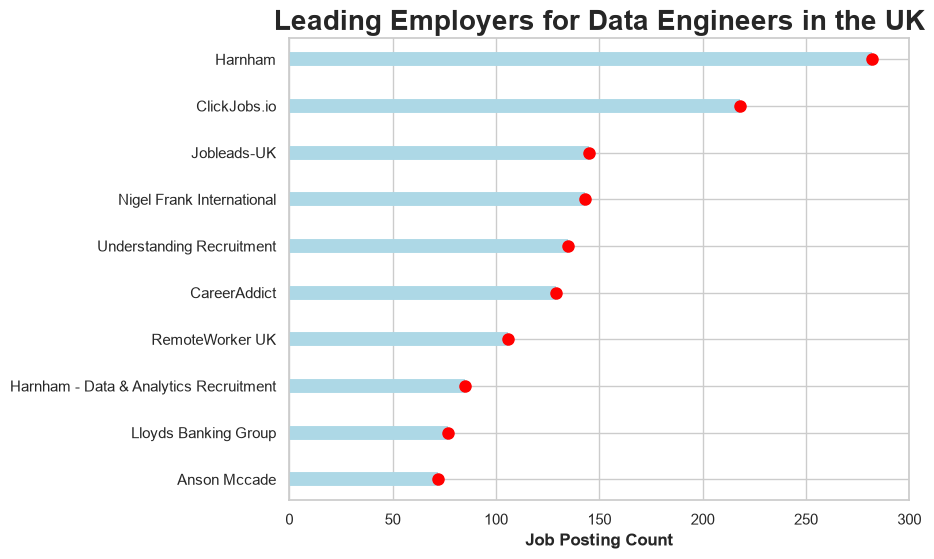

In [137]:
df_plot=df_DE_UK['company_name'].value_counts().head(10).to_frame().reset_index().sort_values(by='count', ascending=True)

plt.figure(figsize=(8,6))

plt.hlines(
    y=df_plot["company_name"],
    xmin=0,
    xmax=df_plot["count"],
    color="lightblue",
    linewidth=10
)

plt.plot(
    df_plot["count"],
    df_plot["company_name"],
    "o",
    markersize=8,
    color='red'
)
plt.xlabel("Job Posting Count",  weight='bold',fontsize=12)
plt.title("Leading Employers for Data Engineers in the UK", weight='bold',fontsize=20)
plt.xlim(0, 300)
plt.show()

##### Most common Job Location in the UK for Data Engineers

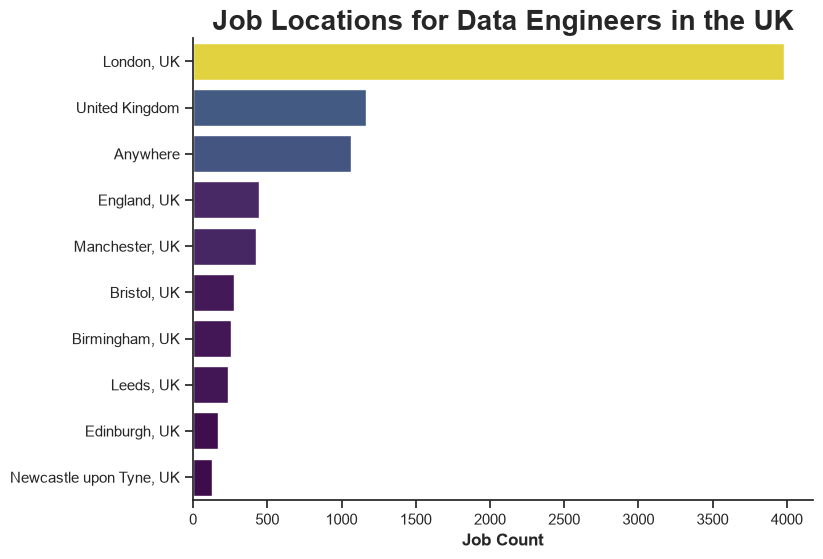

In [138]:
df_plot = df_DE_UK['job_location'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks',rc={'figure.figsize': (8, 6)})
sns.barplot(data=df_plot, x='count', y='job_location', hue='count', palette='viridis', legend=False)
sns.despine()
plt.title('Job Locations for Data Engineers in the UK', weight='bold', fontsize=20)
plt.xlabel('Job Count', fontsize=12, weight='bold')
plt.ylabel('')
plt.show()

##### Skill Trend for Data Engineers in the UK 2023

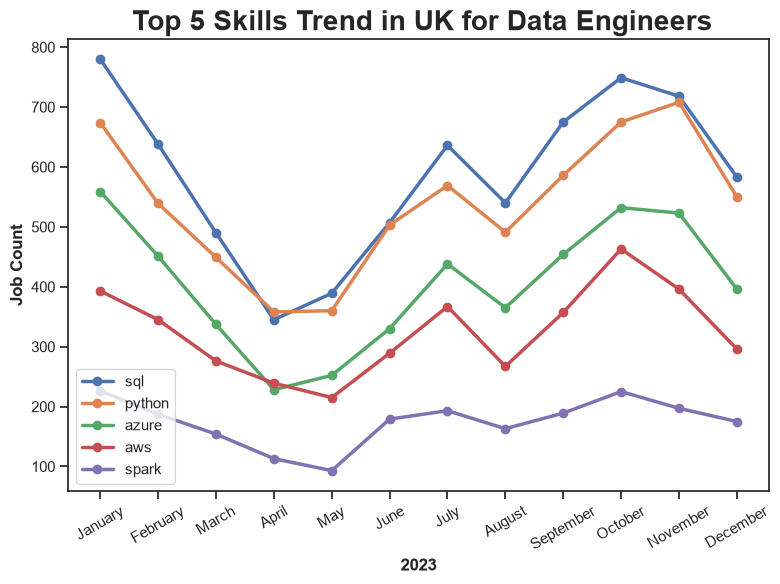

In [142]:

skills_df = df_DE_UK[["job_posted_date", "job_skills"]].dropna().copy()

skills_df['job_posted_month_no']=skills_df['job_posted_date'].dt.month

skills_df_exploded=skills_df.explode('job_skills')

df_pivot=skills_df_exploded.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size',fill_value=0)
df_pivot.loc['total']=df_pivot.sum()
df_pivot=df_pivot[df_pivot.loc['total'].sort_values(ascending=False).index]
df_pivot=df_pivot.drop('total')
df_pivot=df_pivot.reset_index()
df_pivot['job_posted_month']=df_pivot['job_posted_month_no'].apply(lambda x: pd.to_datetime(x,format='%m').strftime("%B"))
df_pivot=df_pivot.set_index('job_posted_month')
df_pivot=df_pivot.drop(columns='job_posted_month_no')

df_pivot=df_pivot.iloc[:,:5]
df_pivot.plot(kind='line',marker="o",figsize=(8, 6), linewidth=2.5)


plt.xticks(ticks=range(len(df_pivot.index)),
           labels=df_pivot.index,
           rotation=30)


plt.title(" Top 5 Skills Trend in UK for Data Engineers", fontsize=20, weight="bold")
plt.xlabel("")
plt.ylabel("Job Count", weight='bold',fontsize=12)
plt.xlabel("2023", weight='bold',fontsize=12)


plt.tight_layout()
plt.legend(loc='lower left')
plt.show()


## 6. Key Findings

## General EDA

**Dataset:** Job postings collected during 2023.

### Job Demand Across All Countries
- Data Analyst, Data Engineer, and Data Scientist are the three most demanded data roles.
- These three positions account for a significantly larger number of job postings than other data-related roles.

### Top Job Posting Platforms
- LinkedIn is the most frequently used platform for advertising data-related jobs.
- It contains considerably more job postings than other job platforms in the dataset.

### Job Opportunities

**Remote Work**
- 91.1% of job postings are non-remote.
- Only 8.9% of job postings offer remote work opportunities.

**Degree Mention**
- 69.4% of job postings do not explicitly mention that a degree is not required.
- Most job advertisements do not state whether a degree is optional.

**Health Insurance**
- Only 11.0% of job postings mention health insurance benefits.
- Employee health insurance is explicitly listed in a relatively small proportion of postings.

### Common Job Schedule Types
- Full-time positions dominate the dataset with more than 600,000 job postings.
- Contractor, part-time, and internship positions appear much less frequently.

### Median Salary Trend
- The monthly median salary remains relatively stable throughout the year.
- Small increases are observed around March and September, while a slight decline appears toward the end of the year.

### Yearly Salary Distribution
- Most yearly salaries are concentrated between **\$50K** and **\$150K**.
- High-paying jobs are relatively uncommon and form a long right tail in the distribution.

### Global Job Demand
- The United States has the largest number of job postings in the dataset.
- Job postings from other countries are considerably lower in comparison.

### Top Global Companies
- Emprego has the highest number of job postings in the dataset.
- The remaining top companies have noticeably fewer postings.

### Top 5 Skills Trend
- SQL and Python remain the two most consistently demanded technical skills throughout the year.
- AWS, Azure, and R also rank among the top five skills with only minor monthly fluctuations.

### Skill Categories
- Programming is the most frequently requested skill category.
- Analyst tools, cloud technologies, and databases are also among the most common skill categories.

### UK EDA

## UK Data Engineer EDA

### Job Demand in the UK
- Data Engineer, Data Analyst, and Data Scientist are the three most common data-related job roles in the UK.
- Data Engineer has the highest number of job postings, indicating particularly strong demand compared to other data roles.

### Top Companies in the UK
- Harnham has the highest number of job postings among companies in the UK dataset.
- This indicates that Harnham was one of the most active recruiters for data-related positions during 2023.

### Job Opportunities in the UK

**Remote Work**
- Only **9.3%** of job postings offer remote work opportunities.
- The remaining **90.7%** of postings are non-remote, indicating that on-site or hybrid positions dominate the UK job market.

**Degree Mention**
- Job postings that mention and do not mention degree flexibility are nearly equally distributed.
- The difference between the two groups is only about **2%**, suggesting no strong preference in how degree requirements are communicated.

**Health Insurance**
- None of the UK job postings in this dataset explicitly mention health insurance benefits.
- This suggests that health insurance was not commonly advertised as part of job postings in the UK dataset.

### UK Data Jobs Salary Distribution
- Most reported yearly salaries are concentrated between **\$90K** and **\$160K**.
- Higher salaries are present but are associated with relatively few job postings, forming the right scewed salary distribution.

### UK and Data Engineering

### Top Companies Hiring Data Engineers in the UK
- Harnham has the highest number of Data Engineer job postings in the UK dataset, making it the most active recruiter.
- ClickJobs.io ranks second, with a considerably lower number of postings than Harnham but a higher number than the remaining companies.

### Job Locations for Data Engineers in the UK
- London, UK is the most common location for Data Engineer job postings by a large margin.
- Other locations, including England, Manchester, Bristol, Birmingham, Leeds, Edinburgh, and Newcastle upon Tyne, have substantially fewer job postings, with each recording fewer than 1,500 postings.

### Top 5 Skills Trend for Data Engineers in the UK
- Monthly demand fluctuates across 2023, with relatively stronger demand observed around **January, July, September, and October**.
- SQL and Python are the two most consistently demanded technical skills throughout the year.
- Azure, AWS, and Spark remain among the top five skills, although they are consistently less demanded than SQL and Python.